# Experiment 3: Fine-tuned Priority Classification

Fine-tunes `roberta-base` with a linear classification head on the large customer support dataset to improve over the zero-shot BART-MNLI baseline established in Experiment 3b.

## 1. Analysis - Zero-shot Baseline & Motivation

The zero-shot BART-MNLI baseline exposed two issues:

**Label-space mismatch**: The model was given five candidate labels, of which `critical` and `very_low` are absent from the English subset. Zero-shot inference has no mechanism to infer the empirical label distribution from data.

**No domain adaptation**: BART-MNLI was pre-trained on MultiNLI, a general-domain corpus. Ticket-specific urgency is outside the pre-training dataset distribution.

Fine-tuning addresses the issues: the model learns the true label distribution and adapts representations to the operational definition of priority in this domain.

In [2]:
import torch
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

## 2. Fine-tuning Decisions & Trade-offs

Model choice - `roberta-base`:  
Different from fine-tuning BART-MNLI: Carries unnecessary decoder overhead for a pure classification task.  
Different from DistilBERT, the mothod is faster but sacrifices ~3-5 F1 points; not preferred given GPU availability.

Classification head - single Linear layer:  
A one-layer projection `Linear(768, 3)` on the CLS token suffices. The representational complexity is already encoded in RoBERTa's 12-layer attention stack.

Dataset split - 6-2-2:  
Stratified sampling preserves the original class ratio across all splits, to prevent the minority class from absence in validation and test.

In [3]:
PROJECT_ROOT = Path.cwd().parents[2]

RESULTS_DIR = PROJECT_ROOT / 'results' / 'Experiment_3_BERTMNLI'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'large_dataset_preprocessed.csv')
df = df[df['priority'].isin(['high', 'medium', 'low'])].reset_index(drop=True)

LABEL2ID = {'high': 0, 'medium': 1, 'low': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
df['label'] = df['priority'].map(LABEL2ID)

train_val, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df, val_df   = train_test_split(train_val, test_size=0.2, stratify=train_val['label'], random_state=42)

## 3. Training Strategy

Optimiser - AdamW, lr = 2e-5:
AdamW decouples weight decay from the gradient update, preventing representation collapse when fine-tuning large pre-trained models. Learning rate 2e-5 is the empirically validated default for RoBERTa classification (Liu et al., 2019).

**Schedule - linear warmup (10% of steps) then linear decay:**
Gradual warm-up prevents large early gradient updates from distorting pre-trained weights before the model has seen sufficient domain data.

**Loss - CrossEntropyLoss with inverse-frequency class weights:**
Class imbalance (high ~38%, medium ~41%, low ~20%) is moderate but non-negligible. Inverse-frequency weighting penalises misclassification of the minority class (`low`) proportionally more, reducing majority-class bias.

**Epochs - 5, early stopping on validation macro F1:**
Five epochs is sufficient for a 17k-sample dataset at this learning rate. The best checkpoint is saved to guard against overfitting in later epochs.

In [4]:
MODEL_NAME = 'roberta-base'
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 5
LR = 2e-5
DEVICE = 0

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt')
        self.labels = torch.tensor(labels.tolist())
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return {k: v[i] for k, v in self.enc.items()}, self.labels[i]

train_ds = TicketDataset(train_df['text_cleaned'], train_df['label'])
val_ds   = TicketDataset(val_df['text_cleaned'], val_df['label'])
test_ds  = TicketDataset(test_df['text_cleaned'], test_df['label'])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE)
print(f'Batches: train={len(train_dl)}  val={len(val_dl)}  test={len(test_dl)}') 

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batches: train=565  val=142  test=177


In [6]:
counts  = train_df['label'].value_counts().sort_index().values
weights = torch.tensor((1.0/counts) / (1.0/counts).sum(), dtype=torch.float).to(DEVICE)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
).to(DEVICE)

loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)

print('Trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 124647939


In [ ]:
best_f1, best_epoch = 0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for batch, labels in train_dl:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = labels.to(DEVICE)
        loss   = loss_fn(model(**batch).logits, labels)
        loss.backward()
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        train_loss += loss.item()

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch, labels in val_dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            preds.extend(model(**batch).logits.argmax(-1).cpu().numpy())
            trues.extend(labels.numpy())

    val_f1  = f1_score(trues, preds, average='macro', zero_division=0)
    val_acc = accuracy_score(trues, preds)
    print(f'Epoch {epoch}  loss={train_loss/len(train_dl):.2f}  val_acc={val_acc:.2f}  val_f1={val_f1:.2f}')

    if val_f1 > best_f1:
        best_f1, best_epoch = val_f1, epoch
        torch.save(model.state_dict(), RESULTS_DIR / 'Experiment_3_finetuned_best.pt')

print(f'best epoch {best_epoch}  val F1={best_f1:.2f}')

## 4. Evaluation 
if you wanner to check the results, please run belowing code

We used the fine-tuned model to calculate the accuracy and f1 truth values ​​on the test set.

In [18]:
from sklearn.metrics import classification_report

model.load_state_dict(torch.load(
    RESULTS_DIR / 'Experiment_3_finetuned_best.pt',
    map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
))
model.eval()

preds, trues = [], []
with torch.no_grad():
    for batch, labels in test_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        preds.extend(model(**batch).logits.argmax(-1).cpu().numpy())
        trues.extend(labels.numpy())

preds_named = [ID2LABEL[p] for p in preds]
trues_named = [ID2LABEL[t] for t in trues]

acc        = accuracy_score(trues_named, preds_named)
f1_macro   = f1_score(trues_named, preds_named, average='macro',    zero_division=0)
f1_weighted = f1_score(trues_named, preds_named, average='weighted', zero_division=0)

print(f'Test Accuracy : {acc:.4f}')
print(f'Test F1 macro : {f1_macro:.4f}')
print(f'Test F1 weighted : {f1_weighted:.4f}')

C:\Users\10525\AppData\Local\Temp\ipykernel_30020\934913154.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


Test Accuracy : 0.6019
Test F1 macro : 0.5943
Test F1 weighted : 0.5997


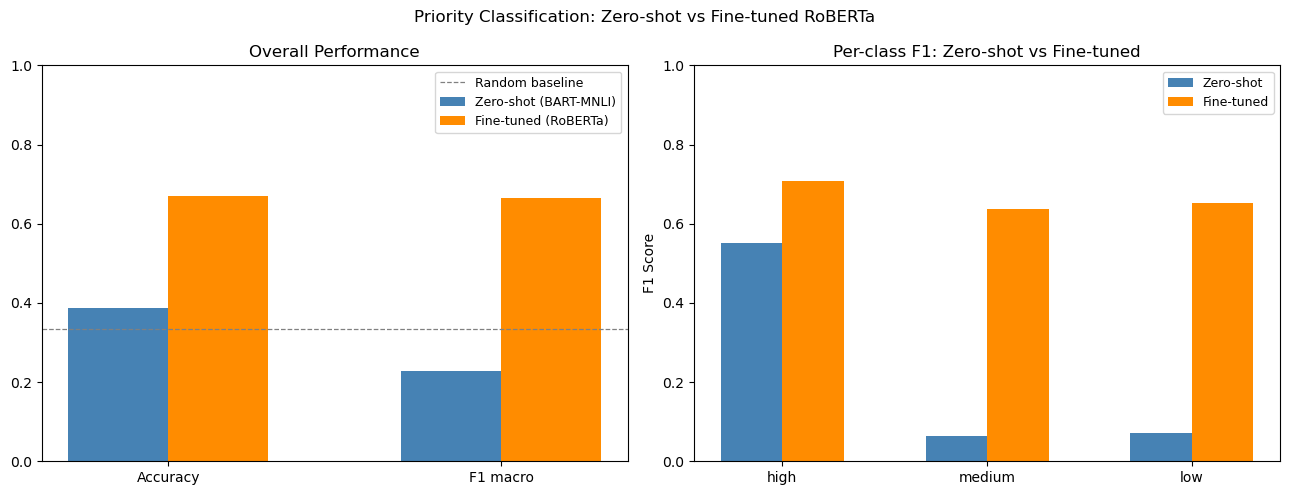

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Load zero-shot predictions on large dataset
zs = pd.read_csv(RESULTS_DIR / 'Experiment_3_zeroshot_large_predictions.csv')
# Filter to shared 3-class ground truth for fair comparison
zs = zs[zs['true'].isin(['high', 'medium', 'low'])].reset_index(drop=True)

CLASSES = ['high', 'medium', 'low']

# Per-class F1 — zero-shot
zs_report = classification_report(zs['true'], zs['pred'], labels=CLASSES,
                                   output_dict=True, zero_division=0)
zs_f1  = [zs_report[c]['f1-score']  for c in CLASSES]
zs_acc = [(zs['true'] == zs['pred']).mean()]  # overall only

# Per-class F1 — fine-tuned
ft_report = classification_report(trues_named, preds_named, labels=CLASSES,
                                   output_dict=True, zero_division=0)
ft_f1  = [ft_report[c]['f1-score']  for c in CLASSES]

# Overall metrics
overall_labels = ['Accuracy', 'F1 macro']
zs_overall  = [accuracy_score(zs['true'], zs['pred']),
               f1_score(zs['true'], zs['pred'], average='macro', labels=CLASSES, zero_division=0)]
ft_overall  = [acc, f1_macro]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(overall_labels))
w = 0.3
axes[0].bar(x - w/2, zs_overall, w, label='Zero-shot (BART-MNLI)', color='steelblue')
axes[0].bar(x + w/2, ft_overall, w, label='Fine-tuned (RoBERTa)',   color='darkorange')
axes[0].axhline(1/3, linestyle='--', color='gray', linewidth=0.9, label='Random baseline')
axes[0].set_xticks(x); axes[0].set_xticklabels(overall_labels)
axes[0].set_ylim(0, 1); axes[0].set_title('Overall Performance')
axes[0].legend(fontsize=9)

x2 = np.arange(len(CLASSES))
axes[1].bar(x2 - w/2, zs_f1, w, label='Zero-shot', color='steelblue')
axes[1].bar(x2 + w/2, ft_f1, w, label='Fine-tuned', color='darkorange')
axes[1].set_xticks(x2); axes[1].set_xticklabels(CLASSES)
axes[1].set_ylim(0, 1); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-class F1: Zero-shot vs Fine-tuned')
axes[1].legend(fontsize=9)

plt.suptitle('Priority Classification: Zero-shot vs Fine-tuned RoBERTa', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_3_comparison.png', dpi=150)
plt.show()